# 🔵 Imports

In [34]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [35]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 🔵 Load data

In [46]:
mnist = fetch_openml('Fashion-MNIST', version=1, parser='auto')
X, y = mnist["data"], mnist["target"].astype(int)


#split data X and y into train and test (80% train and 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Creat a validation set from train (10%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

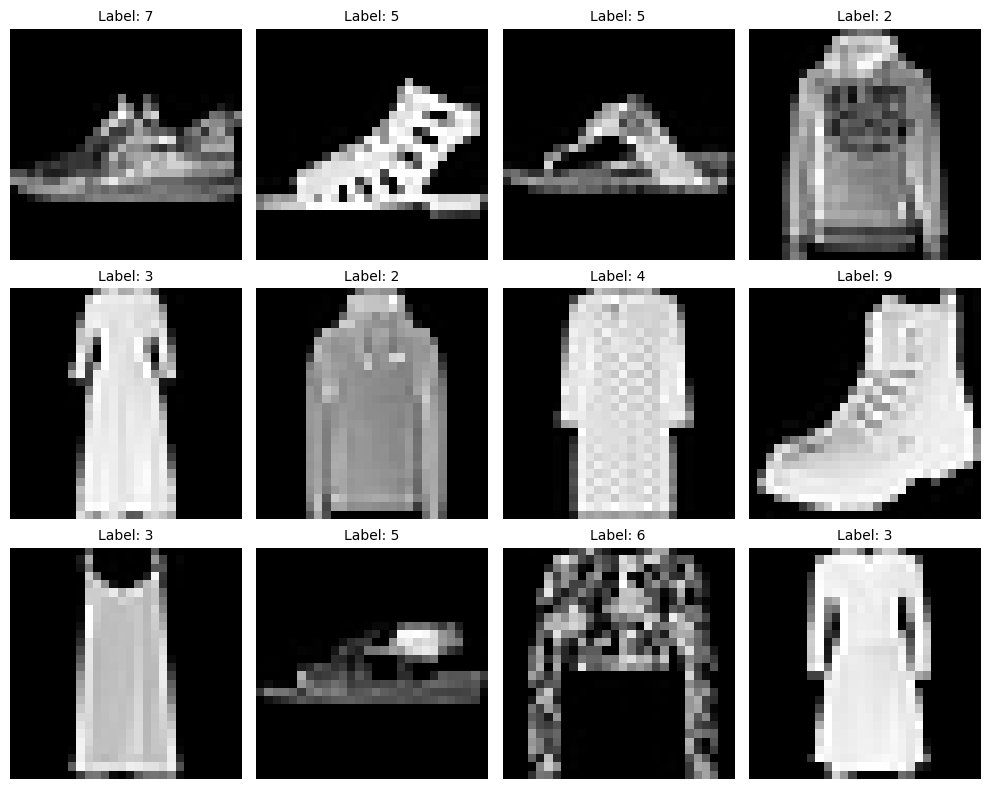

In [47]:
plt.figure(figsize=(10, 8))
random_indices = np.random.randint(0, len(X_train), 12)

for index, pos in enumerate(random_indices):
    plt.subplot(3, 4, index + 1)
    plt.imshow(X_train.iloc[pos].values.reshape(28, 28),
               cmap='gray', vmin=0, vmax=255)
    plt.title(f"Label: {y_train.iloc[pos]}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [48]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def one_hot(y):
    return np.eye(10)[y]

y_train_oh = one_hot(y_train)
y_val_oh = one_hot(y_val)
y_test_oh = one_hot(y_test)

# 🔵 Activation Functions

Rectified Linear Unit (ReLU)

$$  \sigma(x) = \max(0, x)  $$


Sigmoid(logestic)

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$


Hyperbolic Tangent (tanh)

$$ \sigma(x) = \tanh(x) $$



In [54]:
#implement activation functions
def sigmoid(x):
    return (1 / 1 + (np.exp(-x)))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    np.tanh(x)

In [55]:
def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exps = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)

# 🔵 MLP class

In [ ]:
class MLP:
    def __init__(self, layers, activations, lr=0.01):
        self.layers = layers
        self.activations = activations
        self.lr = lr
        self.weights = []
        self.biases = []

        for i in range(len(layers)-1):
            scale = np.sqrt(6.0 / (layers[i] + layers[i+1]))
            self.weights.append(np.random.uniform(-scale, scale, size=(layers[i], layers[i+1])))
            self.biases.append(np.zeros((1, layers[i+1])))

    def forward(self, X):
        self.activations_out = [X]
        self.z_values = []

        #implement forward propagation
        for i in range(len(self.weights)):
            z = np.dot(self.activations_out[-1], self.weights[i]) + self.biases[i]


            self.z_values.append(z)
            act = self.activations[i]
            if act == 'sigmoid':
                a = sigmoid(z)
            elif act == 'relu':
                a = relu(z)
            elif act == 'tanh':
                a = tanh(z)
            elif act == 'softmax':
                a = softmax(z)

            else:
                a = z

            self.activations_out.append(a)

        return self.activations_out[-1]

    def backward(self, X, y):
        m = X.shape[0]
        deltas = [None] * len(self.weights)

        delta = (self.activations_out[-1] - y) / m

        deltas[-1] = delta

        for i in reversed(range(len(self.weights)-1)):
            delta = np.dot(deltas[i+1], self.weights[i+1].T) * self._activation_derivative(self.z_values[i], self.activations[i])
            deltas[i] = delta

        grads_w = []
        grads_b = []
        for i in range(len(self.weights)):
            grad_w = np.dot(self.activations_out[i].T, deltas[i]) / m
            grad_b = np.sum(deltas[i], axis=0, keepdims=True) / m
            grads_w.append(grad_w)
            grads_b.append(grad_b)

        return grads_w, grads_b

    def predict(self, X):
        output = self.forward(X)
        return np.argmax(output, axis=1)

    def _activation_derivative(self, z, activation):
        if activation == 'sigmoid':
            return sigmoid_derivative(z)
        elif activation == 'relu':
            return relu_derivative(z)
        elif activation == 'tanh':
            return tanh_derivative(z)
        
        return 1



    def update_weights(self, grads_w, grads_b): # student ------------------------------------------
       #updata weights with grads and lr
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * grads_w[i]
            self.biases[i]  -= self.lr * grads_b[i]

# 🔵 Train Model

In [59]:
def train_model(hidden_units, activation, lr, epochs=50, batch_size=128):

    #create MLP model
    #first layer should be 784 and last layer should be 10
    model = MLP(
        layers= [784] + hidden_units +[10] ,
        activations = activation + ['softmax'],
        lr= lr,
    )

    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train_oh[i:i+batch_size]

            #forward
            output = model.forward(X_batch)


            #backward
            grads_w, grads_b = model.backward(X_batch, y_batch)

            #updata weights
            model.update_weights(grads_w, grads_b)


        #find accuarcy for train
        train_pred = model.predict(X_train)
        train_acc = np.mean(train_pred == y_train)
        train_accuracies.append(train_acc)

        #find accuarcy for test
        test_pred = model.predict(X_test)
        test_acc = np.mean(test_pred == y_test)
        test_accuracies.append(test_acc)

    return model, train_accuracies, test_accuracies

learning rate is 0.001 and Max Train: 39.86%
Max Test: 39.45%
Best Epoch: 30 
learning rate is 0.01 and Max Train: 73.43%
Max Test: 73.47%
Best Epoch: 30 
learning rate is 0.1 and Max Train: 84.76%
Max Test: 84.19%
Best Epoch: 30 
learning rate is 1 and Max Train: 91.70%
Max Test: 88.44%
Best Epoch: 30 
learning rate is 0.001 and Max Train: 39.28%
Max Test: 39.72%
Best Epoch: 30 
learning rate is 0.01 and Max Train: 71.66%
Max Test: 71.60%
Best Epoch: 30 
learning rate is 0.1 and Max Train: 84.20%
Max Test: 83.30%
Best Epoch: 30 
learning rate is 1 and Max Train: 90.88%
Max Test: 88.11%
Best Epoch: 30 


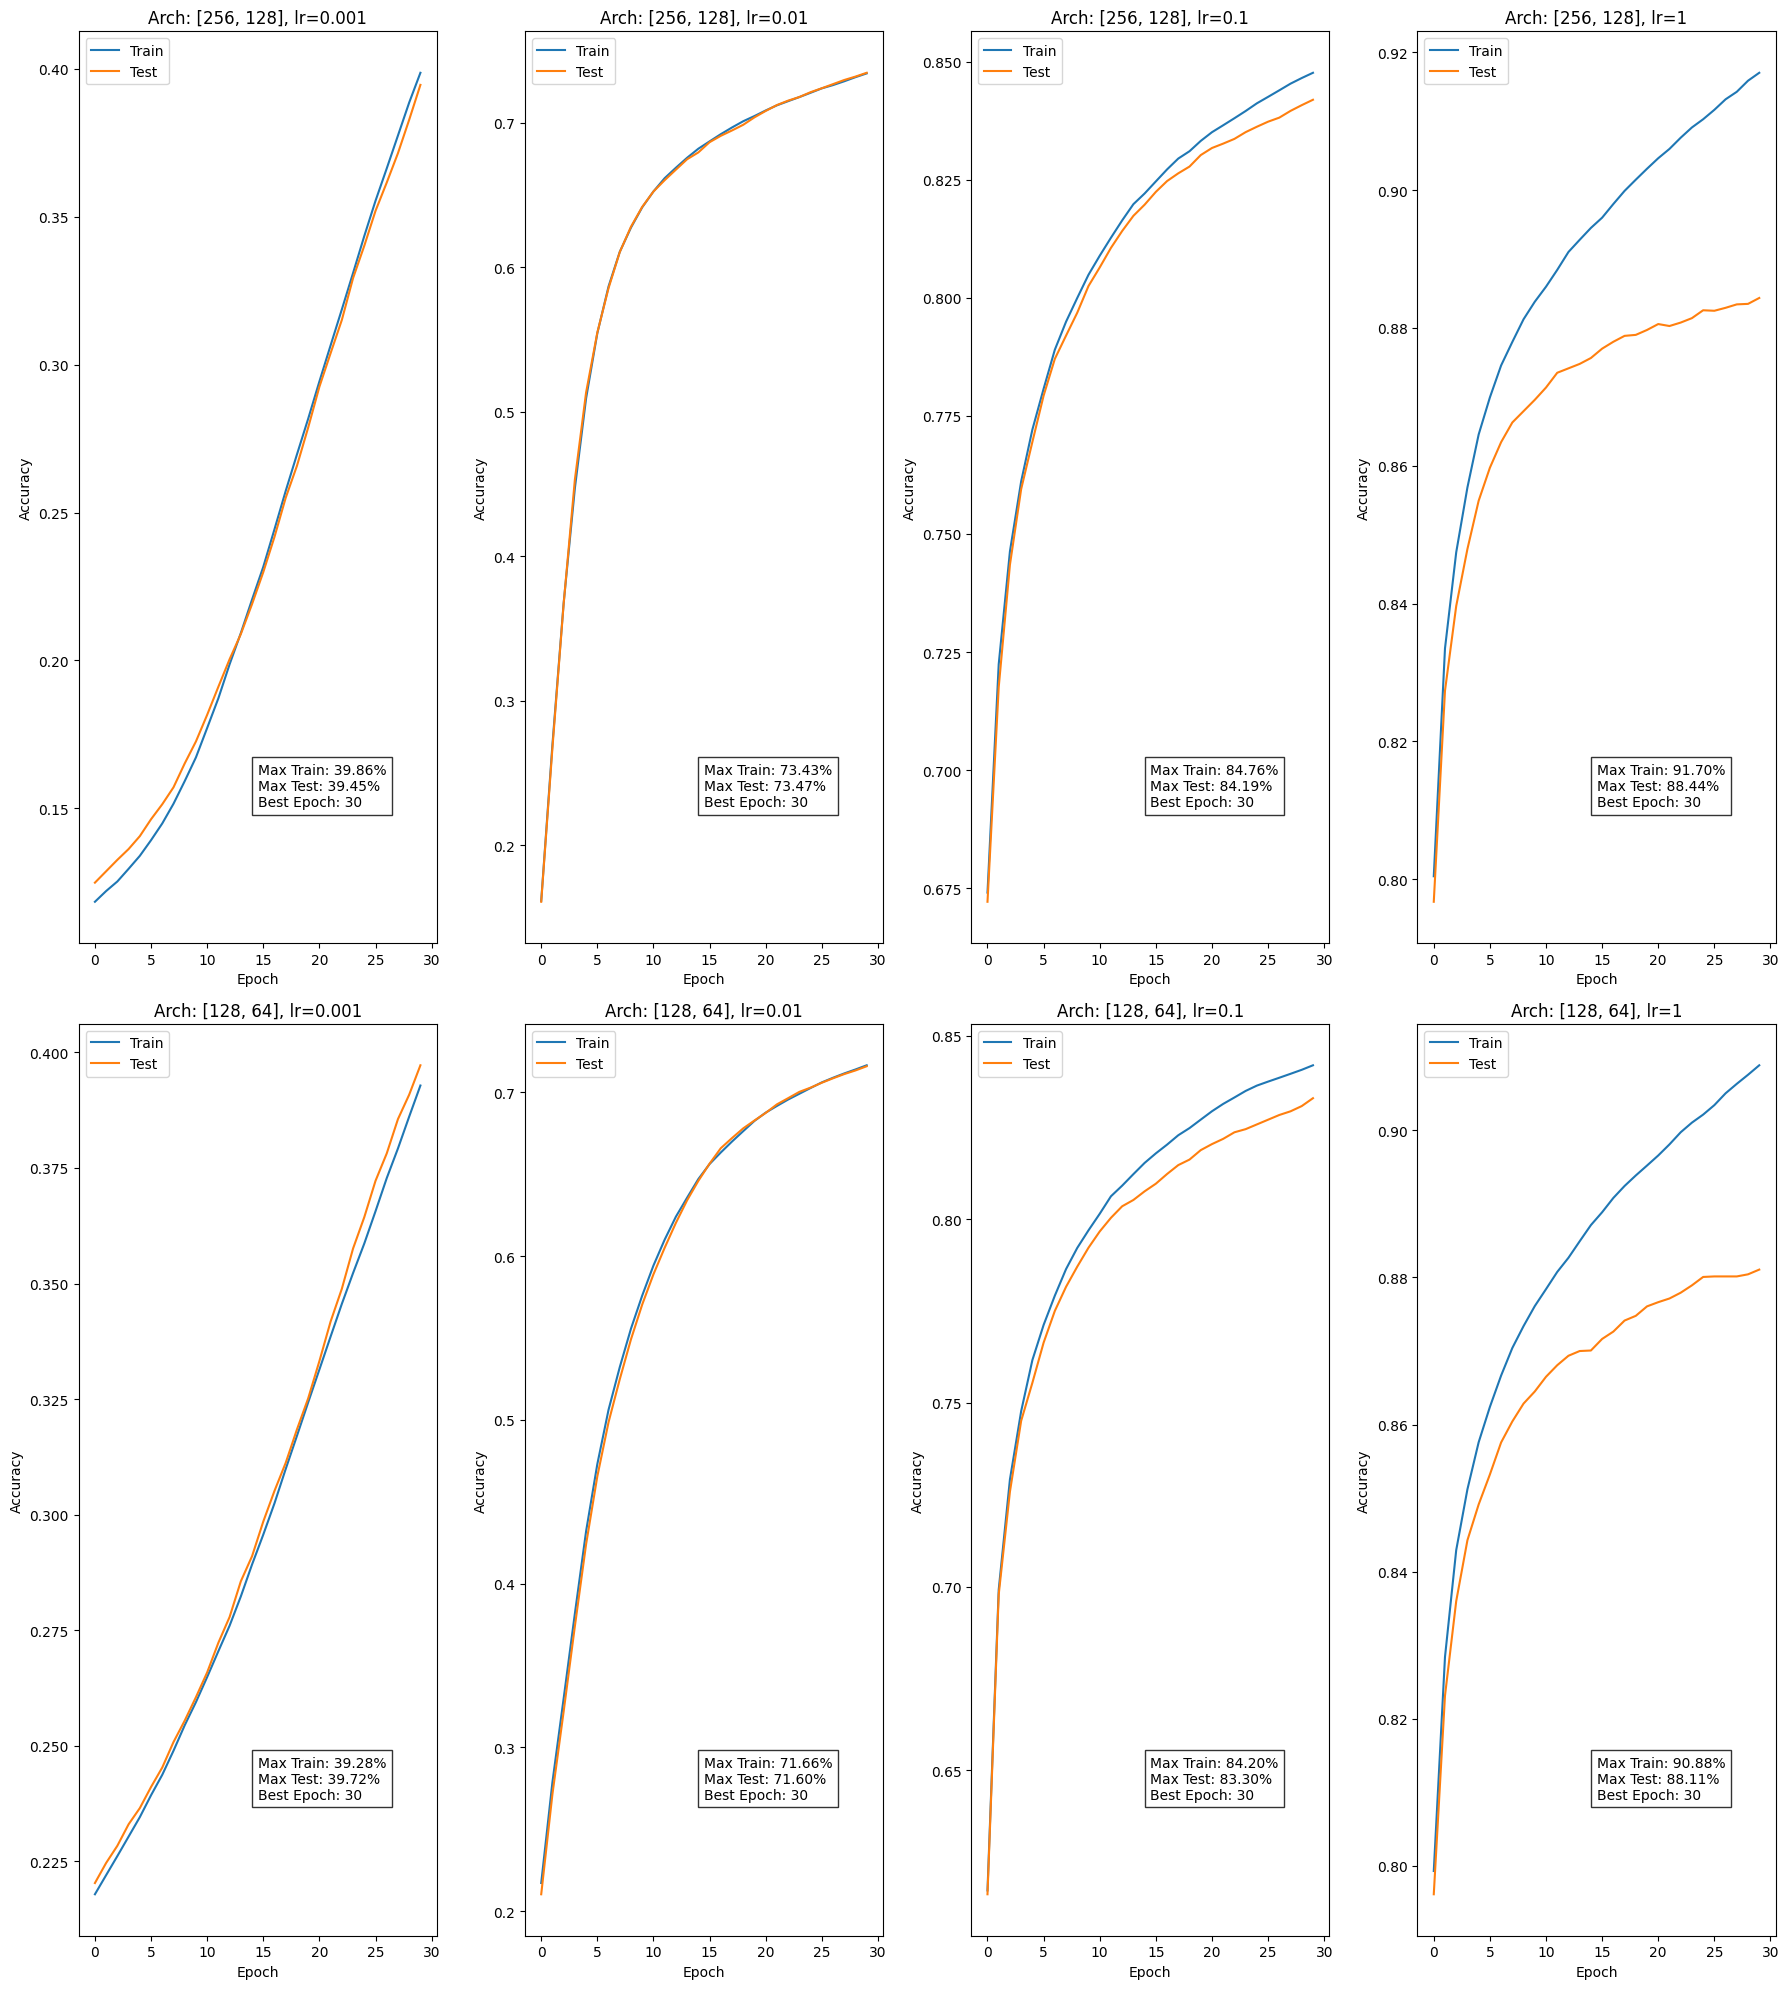

In [61]:
results = []
best_results = []

#create multiple architectures
architectures = [
    [256, 128],
    [128, 64]
]

learning_rates = [0.001, 0.01, 0.1, 1]

# learning_rates = [0.1]
# architectures = [
#     [256, 128],
# ]

plt.figure(figsize=(18, 20))

for i, arch in enumerate(architectures):
    arch_results = []
    for j, lr in enumerate(learning_rates):
        plt.subplot(len(architectures), len(learning_rates), i*len(learning_rates)+j+1)
        # 'sigmoid', 'relu', 'tanh', 'softmax'
        #train your model
        activations = ['relu'] * len(arch)
        _, train_acc, test_acc = train_model(hidden_units=arch, activation = activations, lr = lr, epochs = 30)

        
        max_train = np.max(train_acc)
        max_test = np.max(test_acc)
        best_epoch = np.argmax(test_acc) + 1

        plt.plot(train_acc, label='Train')
        plt.plot(test_acc, label='Test')

        plt.text(0.5, 0.15,
                 f'Max Train: {max_train:.2%}\nMax Test: {max_test:.2%}\nBest Epoch: {best_epoch}',
                 transform=plt.gca().transAxes,
                 bbox=dict(facecolor='white', alpha=0.8))
        print(f"learning rate is {lr} and Max Train: {max_train:.2%}\nMax Test: {max_test:.2%}\nBest Epoch: {best_epoch} ")
        plt.title(f'Arch: {arch}, lr={lr}')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

plt.tight_layout()
plt.show()

# **سوالات**


# **تاثیر لرنینگ ریت های مختلف را در پروسه آموزش برسی کنید و دلیل عملکرد خوب یا بد هرکدام را ذکر کنید**


لرنینگ ریت خیلی پایین باعث پایین شدن دقت مدل میشه و همچنین لرنینگ ریت بیش از حد بالا باعث اورفیت شدن مدلمون میشه، به همین خاطر.

مثلا توی اولی لرنینگ ریت برابر با 0.001 شده 39 درصد که خیلی خیلی کمه

ولی مثلا برای 0.1 دقت تا 84 اومده بالا و بد نیست

برای 1 هم دقت بسیار خوبی داریم که 91 درصده ولی اونقدر تاثیر زیادی رو بالاتر رفتن max_test ما نداشت که این دقیقا نشون دهنده اورفیت شدن مدله


اگه میومدیم epoch رو میبردیم بالا یا یه لرنینگ ریت مثل 10 اضافه میکردیم بهش بعد یهو دقت خیلی میرفت بالا ولی میدیدیم که دقت روی تست اونقدر بالا نمیره و از یه حدی بیشتر نمیشه که این نشون دهنده اورفیت شدن مدلمونه




# **بهترین مدل بین مدل های شما کدام است؟ چرا؟**

بهترین مدل:

learning rate is 1 and Max Train: 91.70%
Max Test: 88.44%
hidden layers:[256, 128],

دلیل اینکه این مدل بهترین نتیجه رو داد مقادیر منطقی و نه خیلی زیاد لرنینگ ریت و epoch بود

دلیل انتخاب هم بالاترین درصد دقت تر train و test رو داره

همچنین مقادیر در نظر گرفته شده برای لایه های مخفی به صورت خوبی باعث افزایش دقت مدل شدن


# **آیا داشتن دقت بالاتر روی داده های آموزش برای انتخاب بهترین مدل کافی است؟ چرا؟ چه پارامتر های دیگری مهم است؟**

همیشه نه. درسته که دق بالاتر داده های آموزشی بسیار مهم است اما همیشه نشون دهنده اینکه مدل خوبه نیست، مثلا یه مدل که بیاد کلاس اکثریت رو پیشبینی کنه دقت بالایی قراره داشته باشه ولی همیشه یک پیشبینی معنادار باهاش نمیشه انجام داد.. 

ملاک های دیگری مثل اینکه مثلا
چقدر طول میکشه تا به یه کوئری جواب بده
یا چیزی مثل اینکه چقدر 
cpu
مصرف میکنه برای اینکه خروجی بده هم مهمه

زمان ترین مهم هست اما چون یباره نسبت به موارد ذکر شده کمتره اهمیتش 

یا چیزهایی مثل اینکه اورفیت نشه
چون از یه حدی بیشتر 
دقت که بالا میره لزوما دقت روی تست بالاتر نمیشه و این میتونه باعث اورفیت شدن مدل بشه درحالی که نباید اورفیت بشه

# 🔵 Test Best Model

In [62]:
#train best model from previous part
# architectures = [
#     [256, 128],
# ]

# learning_rates = [1]
# activations = ['relu'] * len(arch)
best_model, train_acc, test_acc = train_model(hidden_units=[256, 128], activation = ['relu'] * len(arch), lr = 1, epochs = 30)

print(f"Train accuracy: {train_acc[-1]:.2%}")
print(f"Test accuracy: {test_acc[-1]:.2%}")

Train accuracy: 91.72%
Test accuracy: 88.29%


In [71]:
image_name = "images/img_6_label_4.png"

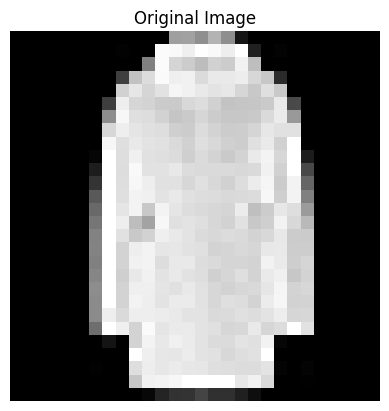

Predicted result: 4


In [72]:
from PIL import Image

image = Image.open(image_name).convert("L")
plt.imshow(np.array(image), cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

image_resized = image.resize((28, 28))
image_array = np.array(image_resized)
image_normalized = image_array / 255.0
image_features = image_normalized.flatten().reshape(1, -1)
result = best_model.predict(image_features)

print("Predicted result:", result[0])